data quality report：缺失值计数、描述统计、重复日期、时间连续性、收益率分布、异常波动日

EDA notebook：Close/Volume/return 时序图，return / log_return 直方图、rolling mean / rolling std、train/val/test 各段统计和可视化标注

add feature: return, log_return

In [1]:
import pandas as pd
import akshare as ak
import numpy as np

In [199]:
ticker = 'AAPL'
df = ak.stock_us_daily(symbol=ticker, adjust="qfq") # 调整方式为前复权

file_path = f"../data/raw/{ticker}_daily.csv"  # ..（两个点）, 代表“返回上一级目录”
df.to_csv(file_path, index=False)  # index=False 表示不保存行索引

df.head()

,date,open,high,low,close,volume
0,1984-09-07,-10.0814,-10.0798,-10.0825,-10.0814,2981600.0
1,1984-09-10,-10.0814,-10.0809,-10.0842,-10.0820,2346400.0
2,1984-09-11,-10.0809,-10.0775,-10.0809,-10.0798,5444000.0
3,1984-09-12,-10.0798,-10.0792,-10.0831,-10.0831,4773600.0
4,1984-09-13,-10.0770,-10.0764,-10.0770,-10.0770,7429600.0


In [200]:
file_path = f"../data/raw/{ticker}_daily.csv"
df = pd.read_csv(file_path)

print(df.info())
print(df.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9902 entries, 0 to 9901
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    9902 non-null   object 
 1   open    9902 non-null   float64
 2   high    9902 non-null   float64
 3   low     9902 non-null   float64
 4   close   9902 non-null   float64
 5   volume  9902 non-null   float64
dtypes: float64(5), object(1)
memory usage: 464.3+ KB
None
              open         high          low        close        volume
count  9902.000000  9902.000000  9902.000000  9902.000000  9.902000e+03
mean     25.401835    25.771510    25.053558    25.427462  2.564770e+07
std      65.869691    66.550077    65.243106    65.925326  2.786220e+07
min     -10.134400   -10.133900   -10.135000   -10.135000  8.880000e+04
25%      -9.902775    -9.897200    -9.909900    -9.902600  7.460553e+06
50%      -9.334350    -9.309100    -9.355850    -9.336100  1.495380e+07
75%      20.598125    20.906250    

In [201]:
start_date = "2015-01-01"
end_date = "2025-01-01"

# 2. 重命名列以匹配 yfinance 的大写格式
rename_map = {
    'date': 'Date',
    'open': 'Open',
    'high': 'High',
    'low': 'Low',
    'close': 'Close',
    'volume': 'Volume'
}
df = df.rename(columns=rename_map)

# 3. 转换数据类型：确保 Date 列是 datetime 格式，并将其设为索引
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

df.head()


,Open,High,Low,Close,Volume
Date,,,,,
1984-09-07,-10.0814,-10.0798,-10.0825,-10.0814,2981600.0
1984-09-10,-10.0814,-10.0809,-10.0842,-10.0820,2346400.0
1984-09-11,-10.0809,-10.0775,-10.0809,-10.0798,5444000.0
1984-09-12,-10.0798,-10.0792,-10.0831,-10.0831,4773600.0
1984-09-13,-10.0770,-10.0764,-10.0770,-10.0770,7429600.0


In [202]:
df.index

DatetimeIndex(['1984-09-07', '1984-09-10', '1984-09-11', '1984-09-12',
               '1984-09-13', '1984-09-14', '1984-09-17', '1984-09-18',
               '1984-09-19', '1984-09-20',
               ...
               '2026-02-25', '2026-02-26', '2026-02-27', '2026-03-02',
               '2026-03-03', '2026-03-04', '2026-03-05', '2026-03-06',
               '2026-03-09', '2026-03-10'],
              dtype='datetime64[ns]', name='Date', length=9902, freq=None)

In [203]:
# 确保 OHLCV 数据是数值型（AkShare 有时返回的数据类型可能是 object）
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 4. 根据 start_date 和 end_date 进行本地切片
# 确保索引是排序好的，否则切片会报错
df = df.sort_index(ascending=True) 
start_dt = pd.to_datetime(start_date)
end_dt = pd.to_datetime(end_date)
df = df.loc[start_dt:end_dt]

df.head()

,Open,High,Low,Close,Volume
Date,,,,,
2015-01-02,18.6400,18.6525,17.6300,18.1250,53096191.0
2015-01-05,17.8650,17.9550,17.1450,17.3550,61065973.0
2015-01-06,17.4275,17.6500,16.9500,17.3575,65565949.0
2015-01-07,17.5925,17.8425,17.4650,17.7300,39723689.0
2015-01-08,18.1000,18.8300,17.9675,18.7600,58761565.0


In [204]:
file_path = f"../data/raw/{ticker}_{start_date}_{end_date}.csv"
df.to_csv(file_path, index=True, index_label='Date')

df.head()

,Open,High,Low,Close,Volume
Date,,,,,
2015-01-02,18.6400,18.6525,17.6300,18.1250,53096191.0
2015-01-05,17.8650,17.9550,17.1450,17.3550,61065973.0
2015-01-06,17.4275,17.6500,16.9500,17.3575,65565949.0
2015-01-07,17.5925,17.8425,17.4650,17.7300,39723689.0
2015-01-08,18.1000,18.8300,17.9675,18.7600,58761565.0


收益率分布

In [205]:
# Calculate returns
df['return'] = df['Close'].pct_change()  # 计算日收益率
df['return']

Date
2015-01-02         NaN
2015-01-05   -0.042483
2015-01-06    0.000144
2015-01-07    0.021460
2015-01-08    0.058094
                ...   
2024-12-24    0.011536
2024-12-26    0.003192
2024-12-27   -0.013309
2024-12-30   -0.013331
2024-12-31   -0.007094
Name: return, Length: 2516, dtype: float64

In [206]:
# Calculate log returns
df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))  # 计算对数收益率

df['log_return']

Date
2015-01-02         NaN
2015-01-05   -0.043412
2015-01-06    0.000144
2015-01-07    0.021233
2015-01-08    0.056469
                ...   
2024-12-24    0.011470
2024-12-26    0.003187
2024-12-27   -0.013398
2024-12-30   -0.013420
2024-12-31   -0.007119
Name: log_return, Length: 2516, dtype: float64

In [207]:
# Drop NaN values (first row will have NaN returns)
df = df.dropna()
df.head()

,Open,High,Low,Close,Volume,return,log_return
Date,,,,,,,
2015-01-05,17.8650,17.9550,17.1450,17.3550,61065973.0,-0.042483,-0.043412
2015-01-06,17.4275,17.6500,16.9500,17.3575,65565949.0,0.000144,0.000144
2015-01-07,17.5925,17.8425,17.4650,17.7300,39723689.0,0.021460,0.021233
2015-01-08,18.1000,18.8300,17.9675,18.7600,58761565.0,0.058094,0.056469
2015-01-09,18.9600,19.1050,18.3450,18.7950,53452528.0,0.001866,0.001864


In [208]:
file_path = f"../data/processed/{ticker}_{start_date}_{end_date}_returns.csv"
df.to_csv(file_path, index=True, index_label='Date')

In [209]:
df.head()

,Open,High,Low,Close,Volume,return,log_return
Date,,,,,,,
2015-01-05,17.8650,17.9550,17.1450,17.3550,61065973.0,-0.042483,-0.043412
2015-01-06,17.4275,17.6500,16.9500,17.3575,65565949.0,0.000144,0.000144
2015-01-07,17.5925,17.8425,17.4650,17.7300,39723689.0,0.021460,0.021233
2015-01-08,18.1000,18.8300,17.9675,18.7600,58761565.0,0.058094,0.056469
2015-01-09,18.9600,19.1050,18.3450,18.7950,53452528.0,0.001866,0.001864


In [210]:
df.describe()

,Open,High,Low,Close,Volume,return,log_return
count,2515.000000,2515.000000,2515.000000,2515.000000,2.515000e+03,2515.000000,2515.000000
mean,90.491445,91.515808,89.539876,90.580031,5.457508e+07,0.001257,0.001042
std,67.347983,68.022708,66.740740,67.428418,3.448117e+07,0.020725,0.020733
min,14.072500,14.490000,13.940000,14.157500,5.199206e+06,-0.140516,-0.151423
25%,30.235000,30.487500,29.678750,30.211250,2.962891e+07,-0.008292,-0.008326
50%,60.587500,61.455000,59.880000,60.672500,4.599215e+07,0.001190,0.001189
75%,148.850000,150.815000,147.070000,149.035000,7.001490e+07,0.012074,0.012001
max,256.900000,258.810000,256.340000,257.730000,3.326072e+08,0.132325,0.124273


In [211]:
df.info

<bound method DataFrame.info of                 Open      High       Low     Close      Volume    return  \
Date                                                                       
2015-01-05   17.8650   17.9550   17.1450   17.3550  61065973.0 -0.042483   
2015-01-06   17.4275   17.6500   16.9500   17.3575  65565949.0  0.000144   
2015-01-07   17.5925   17.8425   17.4650   17.7300  39723689.0  0.021460   
2015-01-08   18.1000   18.8300   17.9675   18.7600  58761565.0  0.058094   
2015-01-09   18.9600   19.1050   18.3450   18.7950  53452528.0  0.001866   
...              ...       ...       ...       ...         ...       ...   
2024-12-24  254.2000  256.9200  254.0000  256.9100  20968585.0  0.011536   
2024-12-26  256.9000  258.8100  256.3400  257.7300  27262774.0  0.003192   
2024-12-27  256.5400  257.4100  251.7700  254.3000  42355256.0 -0.013309   
2024-12-30  250.9400  252.2100  249.4600  250.9100  35557542.0 -0.013331   
2024-12-31  251.1500  251.9900  248.1400  249.1300  3948

In [212]:
df.dtypes  # data types

Open          float64
High          float64
Low           float64
Close         float64
Volume        float64
return        float64
log_return    float64
dtype: object

In [213]:
print(df.index)  # index and its type
print(type(df.index))
print(df.index.dtype)


DatetimeIndex(['2015-01-05', '2015-01-06', '2015-01-07', '2015-01-08',
               '2015-01-09', '2015-01-12', '2015-01-13', '2015-01-14',
               '2015-01-15', '2015-01-16',
               ...
               '2024-12-17', '2024-12-18', '2024-12-19', '2024-12-20',
               '2024-12-23', '2024-12-24', '2024-12-26', '2024-12-27',
               '2024-12-30', '2024-12-31'],
              dtype='datetime64[ns]', name='Date', length=2515, freq=None)
<class 'pandas.core.indexes.datetimes.DatetimeIndex'>
datetime64[ns]


In [214]:
hasattr(df.index, "dtype")  # Return if df.index object has the attribute "dtype"

True

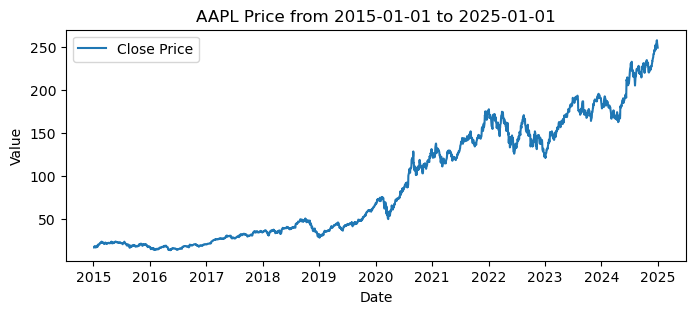

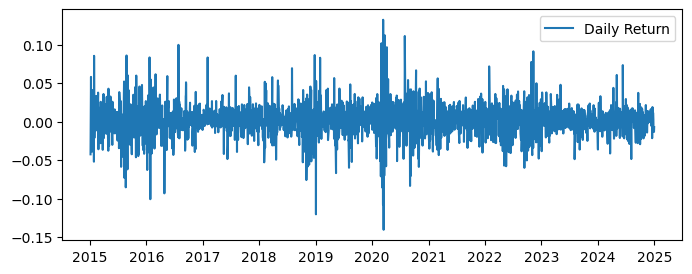

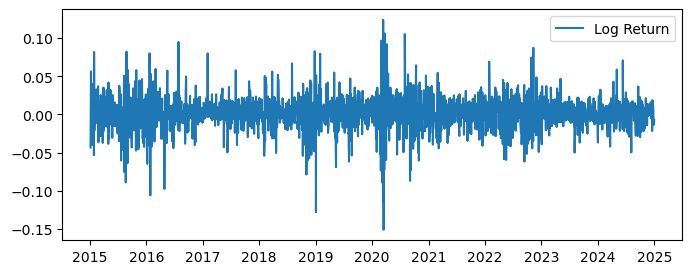

In [215]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 3))
plt.plot(df.index, df['Close'], label='Close Price')
plt.legend()
plt.title(f"{ticker} Price from {start_date} to {end_date}")
plt.xlabel("Date")
plt.ylabel("Value")
plt.show()

plt.figure(figsize=(8, 3))
plt.plot(df.index, df['return'], label='Daily Return')
plt.legend()

plt.figure(figsize=(8, 3))
plt.plot(df.index, df['log_return'], label='Log Return')
plt.legend()

极端波动日

In [216]:
# 计算均值和标准差
mean_val = df['log_return'].mean()
std_val = df['log_return'].std()

# 找出偏离均值 3 倍标准差以上的日期
# 金融数据通常有“重尾”特征，3倍标准差通常能抓到最顶尖的 1% 波动
extremes = df[np.abs(df['log_return'] - mean_val) > 3 * std_val]

print("极端波动日期：")
print(extremes.index)

极端波动日期：
DatetimeIndex(['2015-01-28', '2015-08-11', '2015-08-21', '2015-08-26',
               '2015-09-01', '2016-01-07', '2016-01-22', '2016-01-27',
               '2016-04-27', '2016-07-27', '2017-02-01', '2018-08-01',
               '2018-11-02', '2018-12-26', '2019-01-03', '2019-01-30',
               '2019-05-13', '2019-08-05', '2020-02-27', '2020-03-02',
               '2020-03-09', '2020-03-10', '2020-03-12', '2020-03-13',
               '2020-03-16', '2020-03-20', '2020-03-24', '2020-04-06',
               '2020-07-31', '2020-09-03', '2020-09-08', '2020-10-12',
               '2022-01-28', '2022-09-13', '2022-10-28', '2022-11-10',
               '2024-06-11'],
              dtype='datetime64[ns]', name='Date', freq=None)


In [217]:
# 定义阈值：上下各 0.5%，合计 1%
upper_tail = df['log_return'].quantile(0.995)
lower_tail = df['log_return'].quantile(0.005)

# 筛选出落在这些区间的日期
extremes = df[(df['log_return'] > upper_tail) | (df['log_return'] < lower_tail)]

print("极端波动日期：")
print(extremes.index)

极端波动日期：
DatetimeIndex(['2015-01-28', '2015-08-11', '2015-08-21', '2015-08-26',
               '2016-01-22', '2016-01-27', '2016-04-27', '2016-07-27',
               '2017-02-01', '2018-11-02', '2018-12-26', '2019-01-03',
               '2019-01-30', '2020-02-27', '2020-03-02', '2020-03-09',
               '2020-03-12', '2020-03-13', '2020-03-16', '2020-03-20',
               '2020-03-24', '2020-04-06', '2020-07-31', '2020-09-03',
               '2020-09-08', '2022-11-10'],
              dtype='datetime64[ns]', name='Date', freq=None)


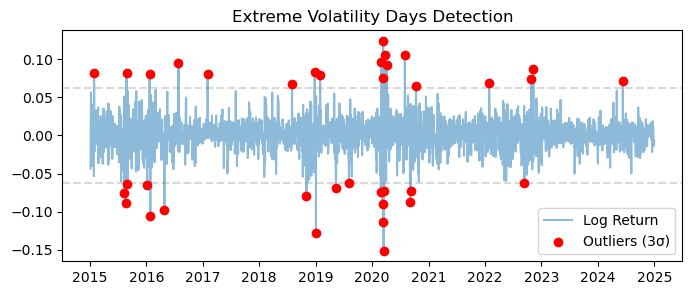

In [218]:
plt.figure(figsize=(8, 3))
# 1. 先画原始收益率曲线
plt.plot(df.index, df['log_return'], label='Log Return', alpha=0.5)

# 2. 找出极端值（假设用 3 sigma）
extremes = df[np.abs(df['log_return'] - df['log_return'].mean()) > 3 * df['log_return'].std()]

# 3. 在对应的坐标点画上红色的点
plt.scatter(extremes.index, extremes['log_return'], color='red', label='Outliers (3σ)', zorder=5)

# 4. 甚至可以加一条阈值水平线
plt.axhline(y=3*std_val, color='gray', linestyle='--', alpha=0.3)
plt.axhline(y=-3*std_val, color='gray', linestyle='--', alpha=0.3)

plt.legend()
plt.title("Extreme Volatility Days Detection")
plt.show()